## Explainability Module

This module checks the model choices with time-series cross-validation, then explains the predictions at three levels: individual orders, the aggregate, and across time.

The reusable pieces (the CV splitter and the explainer class) live in `AnikaAchary_DS_Case_Explainability_2026.py`.

Note: I had assistance from Claude for this section.

In [1]:
%run AnikaAchary_DS_Case_Analysis_2026.ipynb

Baseline (median)    MAE=0.93 days | exact=45.1% | within 1 day=78.7%
Ridge                MAE=0.84 days | exact=44.4% | within 1 day=83.5%
1    6879
2    4836
3     326
4      28
Name: count, dtype: int64


In [2]:
from AnikaAchary_DS_Case_Explainability_2026 import (
    RidgeExplainer, ROUNDED_MAE, describe_splits, numeric_coefs_days_per_unit,
    purged_time_splits, rolling_refit, rounded_mae, to_days,
)

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Config

In [3]:
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.model_selection import GridSearchCV
 
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

For the purpose of testing the robustness of the ridge model, we will use the same train-test split as before: however, we are going to fix 20% of the newest orders as the "holdout" - which will not be touched until the end of this analysis.

Claude brought up a good point here - checking if some of the dev orders started before the cutoff, but finished after it. 

In [4]:
dev = train[tr].copy()
hold = train[~tr].copy()

# Claude suggested to drop orders from dev that finished after cutoff
late = dev["kit_end"] >= cutoff  # label not known yet at the cutoff
print(f"dropping {late.sum()} dev orders whose kit_end is on/after the cutoff ({cutoff.date()})")
dev = dev[~late].reset_index(drop=True)

X_dev, y_dev = make_features(dev), dev["kit_duration"]
X_hold, y_hold = make_features(hold), hold["kit_duration"]

# getting a view of the interval
print(f"dev: {len(dev):>7,} orders  {dev['kit_start'].min().date()} -> {dev['kit_start'].max().date()}")
print(f"holdout: {len(hold):>7,} orders  {hold['kit_start'].min().date()} -> {hold['kit_start'].max().date()}")

dropping 1173 dev orders whose kit_end is on/after the cutoff (2025-11-22)
dev: 141,496 orders  2025-03-04 -> 2025-11-21
holdout:  36,432 orders  2025-11-22 -> 2026-01-31


In order to test the full range of the data, I decided to use k-fold cross validation splits. However, the caveat with this algorithm was with time-series data. Claude said that regular k-fold mixes past and future orders together, so the model would get to train on future orders and predict past ones. 

In order to keep consistent with the time series format, I am implementing each fold to instead train on everything before a point in time, and the validate it on the next block. This same rule will be applied inside each fold (drop training orders that did not finish when the validation block starts)

In [5]:
N_FOLDS = 5
splits = purged_time_splits(dev, n_splits=N_FOLDS)
describe_splits(dev, splits)

,fold,train_rows,train_from,train_to,val_rows,val_from,val_to
0,0,22730,2025-03-04,2025-04-11,23582,2025-04-12,2025-05-24
1,1,46495,2025-03-04,2025-05-23,23582,2025-05-24,2025-07-15
2,2,70053,2025-03-04,2025-07-12,23582,2025-07-15,2025-08-27
3,3,94076,2025-03-04,2025-08-26,23582,2025-08-27,2025-10-11
4,4,117231,2025-03-04,2025-10-10,23582,2025-10-11,2025-11-21


### Model Comparison

The model comparison will consist of the median baseline vs. linear model vs. ridge vs. lasso regression. All models will be scored on the same cross validation splits - the score is MAE on rounded predictions (like `report()` in the previous notebook)

Since preprocessing sits inside the pipeline, the scaler and encoder are re-fit on each training fold only.

In [6]:
grid = [
    {"ridge": [DummyRegressor(strategy="median")]},
    {"ridge": [LinearRegression()]},
    {"ridge": [Ridge()], "ridge__alpha": np.logspace(-2, 3, 11)},
    {"ridge": [Lasso(max_iter=5000)], "ridge__alpha": [1e-4, 1e-3, 1e-2]},
]
# the step is still named "ridge" in the pipeline, it just holds whichever model is being tested
search = GridSearchCV(clone(model), grid, cv=splits, scoring=ROUNDED_MAE, n_jobs=-1, refit=False)
search.fit(X_dev, y_dev)

res = pd.DataFrame(search.cv_results_)
res["model"] = res["param_ridge"].map(lambda m: type(m).__name__)
res["alpha"] = res["param_ridge__alpha"]
res["cv_mae"] = -res["mean_test_score"]
res["cv_mae_se"] = res["std_test_score"] / np.sqrt(N_FOLDS)
res.sort_values("cv_mae").groupby("model").head(1)[["model", "alpha", "cv_mae", "cv_mae_se"]]

,model,alpha,cv_mae,cv_mae_se
15,Lasso,0.01,0.660699,0.061381
0,DummyRegressor,NaN,0.663744,0.026920
12,Ridge,1000.00,0.685862,0.055274
1,LinearRegression,NaN,0.699932,0.044406


Claude suggested to implement a "selection rule": keep the current setting alpha = 1 unless another alpha beats it by more than one standard error across folds.

current alpha=1: CV MAE 0.699
best alpha=1000:    CV MAE 0.686 ± 0.055 (SE)
-> using alpha = 1


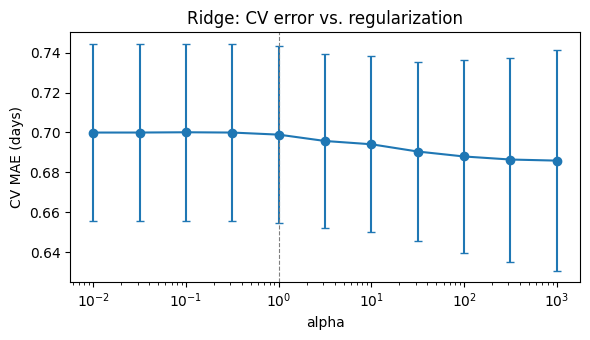

In [7]:
CURRENT_ALPHA = 1.0
rc = res[res["model"] == "Ridge"].assign(alpha=lambda d: d["alpha"].astype(float)).sort_values("alpha")
best = rc.loc[rc["cv_mae"].idxmin()]
cur = rc.loc[rc["alpha"] == CURRENT_ALPHA].iloc[0]
ALPHA = float(best["alpha"]) if cur["cv_mae"] - best["cv_mae"] > best["cv_mae_se"] else CURRENT_ALPHA
print(f"current alpha={CURRENT_ALPHA:g}: CV MAE {cur['cv_mae']:.3f}")
print(f"best alpha={best['alpha']:g}:    CV MAE {best['cv_mae']:.3f} ± {best['cv_mae_se']:.3f} (SE)")
print(f"-> using alpha = {ALPHA:g}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.errorbar(rc["alpha"], rc["cv_mae"], yerr=rc["cv_mae_se"], marker="o", capsize=3)
ax.axvline(ALPHA, color="grey", ls="--", lw=0.8)
ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_ylabel("CV MAE (days)")
ax.set_title("Ridge: CV error vs. regularization"); fig.tight_layout(); plt.show()

### Training Window

To view why the model predicted what it did at the individual order level, I implemented two ideas here: an expanding window (does the model do better on all history?) or only recent orders (sliding window?) 

In [8]:
def cv_scores(splits_, alpha=ALPHA):
    out = []
    for tr_i, va_i in splits_:
        m = clone(model).set_params(ridge__alpha=alpha).fit(X_dev.iloc[tr_i], y_dev.iloc[tr_i])
        out.append(rounded_mae(y_dev.iloc[va_i], m.predict(X_dev.iloc[va_i])))
    return np.array(out)

fold_rows = len(dev) // (N_FOLDS + 1)
n_months = dev["kit_start"].dt.to_period("M").nunique()
windows = {"expanding (all history)": None}
for k in [1, 2, 3]:
    windows[f"sliding, last {k * fold_rows:,} orders (~{k * fold_rows / len(dev) * n_months:.0f} mo)"] = k * fold_rows

win_res = {}
for name, size in windows.items():
    s = cv_scores(purged_time_splits(dev, n_splits=N_FOLDS, max_train_size=size))
    win_res[name] = s
    print(f"{name:<40} MAE {s.mean():.3f} ± {s.std() / np.sqrt(N_FOLDS):.3f}   per fold {np.round(s, 3)}")

exp_name = "expanding (all history)"
best_name = min(win_res, key=lambda k: win_res[k].mean())
best_se = win_res[best_name].std() / np.sqrt(N_FOLDS)
gap = win_res[exp_name].mean() - win_res[best_name].mean()
WINDOW_NAME = best_name if gap > best_se else exp_name
WINDOW = windows[WINDOW_NAME]
print(f"\nbest: {best_name} (gap {gap:.3f} vs SE {best_se:.3f}) -> using: {WINDOW_NAME}")

expanding (all history)                  MAE 0.699 ± 0.044   per fold [0.85  0.777 0.649 0.577 0.642]
sliding, last 23,582 orders (~1 mo)      MAE 0.695 ± 0.040   per fold [0.85  0.714 0.63  0.59  0.693]
sliding, last 47,164 orders (~3 mo)      MAE 0.691 ± 0.048   per fold [0.85  0.777 0.597 0.571 0.662]
sliding, last 70,746 orders (~4 mo)      MAE 0.698 ± 0.047   per fold [0.85  0.777 0.648 0.551 0.663]

best: sliding, last 47,164 orders (~3 mo) (gap 0.008 vs SE 0.048) -> using: expanding (all history)


### Checking stability across folds

This cell contains error, bias (positive = over-predicting), and the numeric coefficients for each fold. Claude said to have the coefficients are converted back to days per unit so they can be compared across folds.

,val_from,mae,median_baseline_mae,bias
0,2025-04-12,0.850,0.718,0.378
1,2025-05-24,0.777,0.680,0.405
2,2025-07-15,0.649,0.603,0.209
3,2025-08-27,0.577,0.584,0.111
4,2025-10-11,0.642,0.734,-0.158


,order_amt,quantity_produced,line_qty,days_to_kit_start,days_to_ship
2025-04-12,0.014,0.011,-0.051,-0.023,-0.0
2025-05-24,0.013,-0.018,-0.013,-0.014,-0.0
2025-07-15,0.015,-0.018,-0.006,-0.009,-0.0
2025-08-27,0.010,-0.022,-0.000,-0.001,0.0
2025-10-11,0.009,-0.014,-0.007,-0.001,0.0


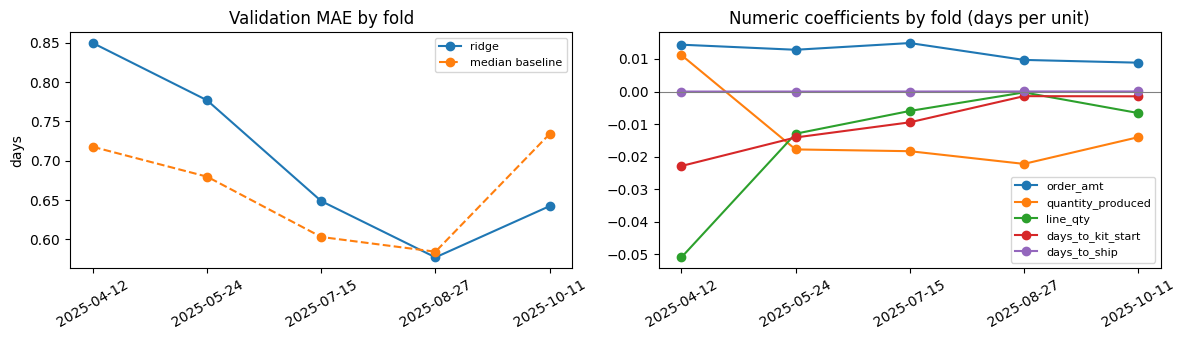

In [9]:
rows, coef_rows = [], []
for tr_i, va_i in purged_time_splits(dev, n_splits=N_FOLDS, max_train_size=WINDOW):
    m = clone(model).set_params(ridge__alpha=ALPHA).fit(X_dev.iloc[tr_i], y_dev.iloc[tr_i])
    p_ = m.predict(X_dev.iloc[va_i])
    label = dev["kit_start"].iloc[va_i[0]].strftime("%Y-%m-%d")
    rows.append({"val_from": label,
                 "mae": rounded_mae(y_dev.iloc[va_i], p_),
                 "median_baseline_mae": np.mean(np.abs(y_dev.iloc[tr_i].median() - y_dev.iloc[va_i])),
                 "bias": np.mean(to_days(p_) - y_dev.iloc[va_i])})
    coef_rows.append(numeric_coefs_days_per_unit(m, NUMS).rename(label))
fold_df, fold_coefs = pd.DataFrame(rows), pd.DataFrame(coef_rows)
display(fold_df.round(3), fold_coefs.round(3))

# Claude assisted with the visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(fold_df["val_from"], fold_df["mae"], marker="o", label="ridge")
axes[0].plot(fold_df["val_from"], fold_df["median_baseline_mae"], marker="o", ls="--", label="median baseline")
axes[0].legend(fontsize=8); axes[0].set_title("Validation MAE by fold"); axes[0].set_ylabel("days")
for c in fold_coefs:
    axes[1].plot(fold_coefs.index, fold_coefs[c], marker="o", label=c)
axes[1].axhline(0, color="grey", lw=0.8); axes[1].legend(fontsize=8)
axes[1].set_title("Numeric coefficients by fold (days per unit)")
for a in axes: a.tick_params(axis="x", rotation=30)
fig.tight_layout(); plt.show()

### Check the holdout data

Refit chosen config on dev and score once on the holdout. Claude suggested to add the "check rows" - they show what CV's runner-ups would have done

In [10]:
fit_rows = slice(None) if WINDOW is None else slice(-WINDOW, None)
final = clone(model).set_params(ridge__alpha=ALPHA).fit(X_dev.iloc[fit_rows], y_dev.iloc[fit_rows])

report("Baseline (median)", np.full(len(y_hold), y_dev.median()), y_hold)
report(f"Ridge (alpha={ALPHA:g})", to_days(final.predict(X_hold)), y_hold)

for name, a, w in [("alpha=1000", 1000, None), ("1-month window", ALPHA, windows[list(windows)[1]])]:
    sl = slice(None) if w is None else slice(-w, None)
    m = clone(model).set_params(ridge__alpha=a).fit(X_dev.iloc[sl], y_dev.iloc[sl])
    report(f"  check: {name}", to_days(m.predict(X_hold)), y_hold)

hold["pred_raw"] = final.predict(X_hold)
hold["pred_days"] = to_days(hold["pred_raw"])
hold["abs_err"] = (hold["pred_days"] - hold["kit_duration"]).abs()

Baseline (median)    MAE=0.93 days | exact=45.1% | within 1 day=78.7%
Ridge (alpha=1)      MAE=0.85 days | exact=43.8% | within 1 day=83.5%
  check: alpha=1000  MAE=0.85 days | exact=44.3% | within 1 day=84.0%
  check: 1-month window MAE=0.94 days | exact=38.4% | within 1 day=81.2%


### Explaining the predictions

Since ridge regression is linear, every prediction splits exactly into a baseline (avg prediction), plus one contribution per feature, measured in days.

While chatting with Claude about this, it brought up how this matches that this matches what the SHAP library's linear explainer gives (hence no extra library needed). The one-hot columns are added back together, so `family_desc` shows up as one number instead of 360 dummy cols.

In [11]:
explainer = RidgeExplainer(final, X_dev.iloc[fit_rows], NUMS, CATS)
print(f"baseline (average prediction): {explainer.baseline:.2f} days")

baseline (average prediction): 1.30 days


### Individual orders

Claude said that there are three holdout orders: a typical one, the longest prediction, and the biggest miss.

For the visualizations, red bars push the prediction up, while blue bars push it down.


typical order: sales_order_id 1028465043


,value,contribution_days
kit_start_dow,3,-0.162
download_dow,2,0.102
family_desc,HMFRUNTS UJ,0.087
tie_num,1,0.042
quantity_produced,2.0,0.024
mcid,KHO,-0.010



longest predicted: sales_order_id 1026255950


,value,contribution_days
family_desc,PJJHMN IXX,7.010
kit_start_dow,5,0.753
download_dow,1,0.102
quantity_produced,1.0,0.042
tie_num,1,0.042
mcid,KL1,-0.038



biggest miss: sales_order_id 1028022181


,value,contribution_days
kit_start_dow,5,0.753
family_desc,XMJQITS TJRCJ,-0.374
download_dow,0,0.102
quantity_produced,8.0,-0.087
line_qty,8.0,-0.042
tie_num,1,0.042


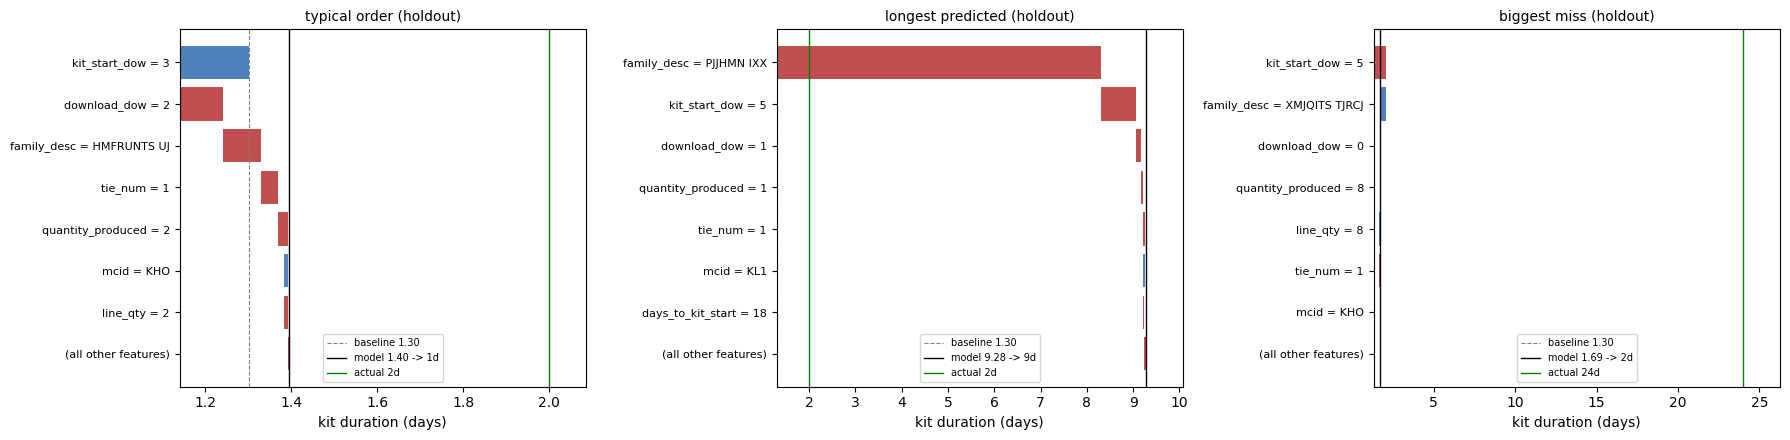

In [12]:
picks = {
    "typical order": (hold["pred_raw"] - hold["pred_raw"].median()).abs().idxmin(),
    "longest predicted": hold["pred_raw"].idxmax(),
    "biggest miss": hold["abs_err"].idxmax(),
}

# Claude assisted with the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for a, (name, idx) in zip(axes, picks.items()):
    t = explainer.explain_order(X_hold.loc[[idx]], actual=y_hold.loc[idx], ax=a, title=f"{name} (holdout)", top=7)
    print(f"\n{name}: sales_order_id {hold.loc[idx, 'sales_order_id']}")
    display(t.head(6).round(3))
fig.tight_layout(); plt.show()

In the inference set, we can use the same breakdown for an order - the model that produced `predictions.npy`. Claude said this would be the version that a planner would see next to the prediction date.

inference sales_order_id 1028144919, predicted kit_end 2026-02-25


,value,contribution_days
family_desc,UFQT UNSYT UJ,1.593
kit_start_dow,5,0.677
download_dow,3,0.095
is_cfi,1,0.049
days_to_kit_start,30,0.036
tie_num,1,0.035
(all other features),,0.081


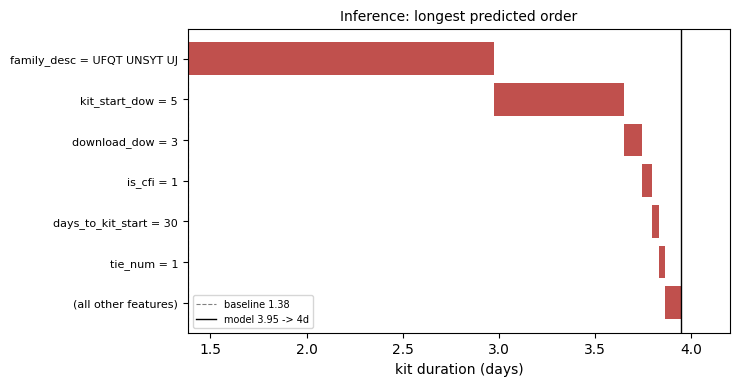

In [13]:
inf_explainer = RidgeExplainer(model, X, NUMS, CATS)  # `model` = fit on all training orders, above
i = int(np.argmax(model.predict(X_inf)))
print(f"inference sales_order_id {inference['sales_order_id'].iloc[i]}, predicted kit_end {kit_end_pred.iloc[i].date()}")
inf_explainer.explain_order(X_inf.iloc[[i]], title="Inference: longest predicted order", top=6).round(3)

### Aggregate

### 2. Aggregate

Which features drive predictions overall:
- **mean |contribution|**: how many days, on average, each feature moves a prediction
- **permutation importance**: how much holdout MAE gets worse when that feature is shuffled. This checks that the feature actually helps accuracy, not just that the model leans on it.

,mean_abs_contribution_days,share_of_total,perm_importance_mae_increase
kit_start_dow,0.349,0.378,0.139
family_desc,0.281,0.304,0.092
download_dow,0.102,0.110,0.000
tie_num,0.066,0.072,0.021
quantity_produced,0.048,0.052,0.008
line_qty,0.021,0.023,0.004
mcid,0.020,0.022,-0.000
order_amt,0.017,0.019,-0.000
days_to_kit_start,0.009,0.010,0.001
buid,0.008,0.009,0.001


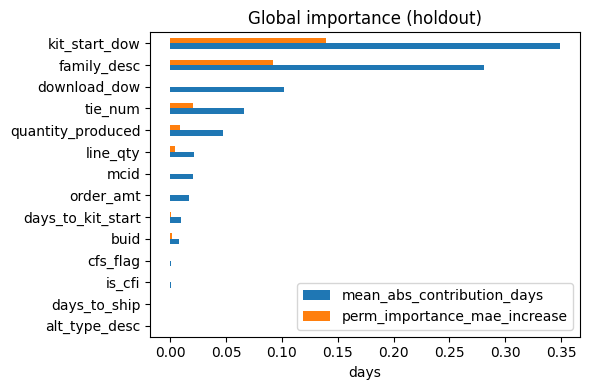

In [14]:
gi = explainer.global_importance(X_hold, y_hold)
display(gi.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
gi[["mean_abs_contribution_days", "perm_importance_mae_increase"]][::-1].plot.barh(ax=ax)
ax.set_xlabel("days"); ax.set_title("Global importance (holdout)"); fig.tight_layout(); plt.show()

We know that `family_desc` has ~360 levels, so here are the product families add or remove the most days compared with the avg order (families with at least 100 dev orders)

In [15]:
fam = explainer.level_effects("family_desc", X_dev, min_orders=100)
display(pd.concat([fam.head(5), fam.tail(5)]).round(2))

,effect_days,n_orders
XMJQITS TJRCJIXX,-0.66,162
HFXF GQFSHF IXX,-0.63,167
XMJQITS IXX,-0.62,133
GWFETX AXFSWS,-0.44,113
DJYN XRFQQKTTY TJRW,-0.43,610
QJTS UJ,1.22,411
XYJJIF IXX,1.39,279
PJJHMN UJ,1.59,482
LRFXYJWKZQQ JC5000,2.05,102
RTXX IXX,2.82,328


Something that Claude mentioned was to explore the importance on the inference set (no labels, so contributions only). This shows whether the orders we're predicting rely on the same features as the holdout.

In [16]:
inf_explainer.global_importance(X_inf).round(3)

,mean_abs_contribution_days,share_of_total
family_desc,0.286,0.331
kit_start_dow,0.248,0.287
download_dow,0.095,0.110
tie_num,0.054,0.063
is_cfi,0.049,0.057
line_qty,0.039,0.045
quantity_produced,0.033,0.038
mcid,0.022,0.026
order_amt,0.018,0.021
buid,0.008,0.009


### Across time

### 3. Across time

- **Rolling refit**: Claude said to refit the model on 60-day windows across the whole timeline and track how much each feature drives predictions. This is descriptive only: it shows drift, it isn't an evaluation.
- **Holdout by week**: Another thing to think about is how much each feature drives predictions in each week, and how the error moves week to week.
- **Target shift**: how the distribution of kit durations changed between dev and holdout.

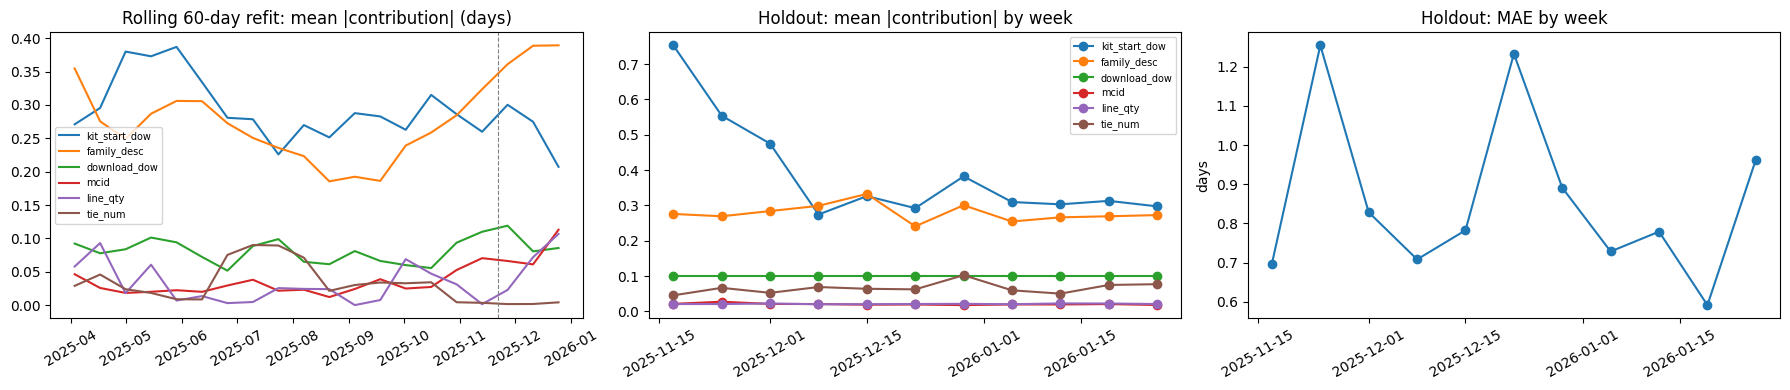

,holdout MAE
kit_start,
2025-11-17,0.698
2025-11-24,1.255
2025-12-01,0.828
2025-12-08,0.708
2025-12-15,0.782
2025-12-22,1.233
2025-12-29,0.891
2026-01-05,0.728
2026-01-12,0.779


In [17]:
roll_coefs, roll_imp = rolling_refit(clone(model).set_params(ridge__alpha=ALPHA), X, y,
                                     train["kit_start"], NUMS, CATS, window_days=60, step_days=14)
weekly_contrib = explainer.contributions_by_period(X_hold, hold["kit_start"], freq="W", signed=False)
weekly_err = hold.groupby(hold["kit_start"].dt.to_period("W"))["abs_err"].mean()
weekly_contrib.index = weekly_contrib.index.start_time
weekly_err.index = weekly_err.index.start_time

top = roll_imp.mean().sort_values(ascending=False).index[:6]  # keep the plots readable
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for c in top:
    axes[0].plot(roll_imp.index, roll_imp[c], label=c)
axes[0].axvline(cutoff, color="grey", ls="--", lw=0.8)
axes[0].legend(fontsize=7); axes[0].set_title("Rolling 60-day refit: mean |contribution| (days)")
for c in top:
    axes[1].plot(weekly_contrib.index, weekly_contrib[c], marker="o", label=c)
axes[1].legend(fontsize=7); axes[1].set_title("Holdout: mean |contribution| by week")
axes[2].plot(weekly_err.index, weekly_err.values, marker="o")
axes[2].set_title("Holdout: MAE by week"); axes[2].set_ylabel("days")
for a in axes: a.tick_params(axis="x", rotation=30)
fig.tight_layout(); plt.show()

display(weekly_err.round(3).rename("holdout MAE").to_frame())

In [18]:
shift = pd.DataFrame({"dev": y_dev.clip(upper=5).value_counts(normalize=True),
                      "holdout": y_hold.clip(upper=5).value_counts(normalize=True)}).sort_index()
shift.index = [*map(str, shift.index[:-1]), "5+"]
shift.index.name = "kit_duration (days)"
shift.round(3)

,dev,holdout
kit_duration (days),,
0,0.212,0.141
1,0.497,0.451
2,0.164,0.196
3,0.082,0.124
4,0.028,0.060
5+,0.018,0.029


### Design choices

**Validation.** I kept the original oldest-80% / newest-20% split as the final holdout and did all tuning inside the 80% with forward-chaining CV (using `TimeSeriesSplit`). However, I did not know how to approach k-folds with time series data, and after chatting with Claude I learned it was because regular k-fold would let the model train on future orders. Any order that hadn't finished by a cutoff is purged from training, since its `kit_end` wouldn't be known yet. Scaling and encoding are fit inside each fold. All scores are MAE on rounded, clipped predictions to match what's submitted.

**Model and settings.** I compared a median baseline, linear regression, Ridge across alphas, and Lasso, and tested expanding vs. sliding training windows. The rule was to keep the current setup unless something beat it by more than one standard error. Nothing did: alpha barely matters (CV MAE 0.70 → 0.69 from alpha 1 to 1000, SE ≈ 0.05), and the windows were within 0.01 of each other. So the model stays Ridge with alpha = 1 on all history. On the holdout it gets **0.85 days MAE vs. 0.93 for the median baseline**, with 83.5% of orders within a day vs. 78.7%. (This is 0.01 higher than the earlier 0.84 because of the purge.) In the earlier CV folds Ridge doesn't clearly beat the median, and it over-predicts by about 0.4 days, so the signal is real but modest.

**Explanations.** Because Ridge is linear, each prediction splits exactly into a baseline plus per-feature contributions in days. That's the same as SHAP for a linear model, so it needs no extra library, and the one-hot columns roll up to their original feature. I use that one decomposition for all three levels: waterfalls for single orders, mean |contribution| plus permutation importance for the aggregate, and weekly contributions plus rolling refits for time.

**Results**
- **Product family and kit-start weekday drive most predictions.** `family_desc` and `kit_start_dow` account for about two-thirds of the explained variation. Kits that start on a Saturday run about 0.7 days longer than average, and Tue–Wed starts run about 0.3 days shorter, likely because the duration counts weekend days. The numeric features barely matter.
- **Error spikes in holiday weeks.** Weekly holdout error jumps around Thanksgiving and Christmas (about 1.2 days vs. 0.6–0.9 in other weeks), and the model has no holiday information.
- **Kits got slower in the holdout period.** 3+ day kits rose from about 13% of dev orders to about 21%.

**Next steps.** Claude said to add holiday and working-day features from `calendar.parquet`, try predicting business days instead of calendar days, and look at a median-targeted model (e.g. quantile regression), since MAE rewards the median and Ridge fits the mean.